# Team Profiles & Elo Rankings — FIFA World Cup 2026
### Building team profiles and preparing Elo ratings for match prediction

**Goal:** Two outputs for the rest of the pipeline:
1. **Elo ratings** for match prediction & tournament simulation (notebooks 03–04)
2. **Team profiles** for the React dashboard — how each team plays, scored against the historical World Cup champion benchmark from notebook 01

**Key design decision:** The FIFA Elo system updates after every international match (friendlies, qualifiers, Nations League, continental tournaments, World Cup) and already weights results by opponent strength and match importance. This means **Elo already captures form** — a team on a hot streak sees their Elo climb. We use pure Elo for prediction to avoid double-counting recent results.

**Data Sources:**
- FIFA Elo rankings (March 2026) — 48 qualified teams
- 16 recent performance datasets (2023–2026) — for team profile metrics

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.insert(0, '../src/data_collection')

%matplotlib inline

from fifa_rankings import FIFA_RANKINGS
from wc_2026_schedule import GROUPS, TOURNAMENT_FORMAT

# Champion benchmark from notebook 01 (historical WC champion per-match averages)
CHAMPION_BENCHMARK = {
    'shot_conversion': 15.12,
    'defensive_save_rate': 93.54,
    'xg_overperformance': 0.19,
    'goal_difference': 1.46,
    'possession': 53.54,
    'shot_dominance': 1.75,
}

print(f"Loaded {len(FIFA_RANKINGS)} team rankings")
print(f"Loaded {len(GROUPS)} groups with {sum(len(v) for v in GROUPS.values())} teams")

Loaded 50 team rankings
Loaded 12 groups with 48 teams


## 2. FIFA Elo Rankings

The FIFA ranking system (since 2018) uses a modified Elo formula that updates after **every** international match:
- `P = Pbefore + I × (W − We)` where `I` = match importance weight
- `We = 1 / (10^(-dr/600) + 1)` — expected score based on rating difference

This already accounts for opponent strength, match importance (friendly vs qualifier vs World Cup), and recent form. A team's current Elo is the cumulative product of all their recent results.

In [2]:
# Create rankings dataframe
rankings_df = pd.DataFrame([
    {"team": team, "elo": elo}
    for team, elo in FIFA_RANKINGS.items()
]).sort_values("elo", ascending=False).reset_index(drop=True)

rankings_df.index += 1
rankings_df.index.name = "fifa_rank"

# Identify which group each team is in
team_to_group = {}
for group, teams in GROUPS.items():
    for team in teams:
        team_to_group[team] = group

rankings_df["group"] = rankings_df["team"].map(team_to_group)

# Flag WC 2026 qualified teams
rankings_df["in_wc2026"] = rankings_df["group"].notna()
wc_teams = rankings_df[rankings_df["in_wc2026"]].copy()

print(f"WC 2026 teams with Elo ratings: {len(wc_teams)}")
print(f"Elo range: {wc_teams['elo'].min()} — {wc_teams['elo'].max()}")
print()
wc_teams[["team", "elo", "group"]].head(15)

WC 2026 teams with Elo ratings: 48
Elo range: 1360 — 1877



,team,elo,group
fifa_rank,,,
1,Spain,1877,H
2,Argentina,1873,J
3,France,1870,I
4,England,1834,L
5,Brazil,1760,C
6,Portugal,1760,K
7,Netherlands,1756,F
8,Morocco,1736,C
9,Belgium,1730,G


## 3. Load Recent Performance Data

We aggregate team statistics from 16 data sources to build team profiles. These capture **how** each team plays — not how strong they are (that's Elo's job).

**Sources:** WC Qualifiers (7), Friendlies (3), Nations League (2), AFCON (2), Euro 2024, Copa America 2024

In [3]:
# Load recent form data from 16 sources
# Sources: WC Qualifiers (7), Friendlies (3), Nations League (2), AFCON (2), Euro 2024, Copa 2024
# We need: shot_conversion, defensive_save_rate, xg_overperformance, goal_difference, possession

team_level_files = [
    # WC Qualifiers
    '../data/raw/qualifiers/international-wc-qualification-europe-teams-2026-to-2026-stats.csv',
    '../data/raw/qualifiers/international-wc-qualification-south-america-teams-2023-to-2026-stats.csv',
    '../data/raw/qualifiers/international-wc-qualification-concacaf-teams-2026-to-2026-stats.csv',
    '../data/raw/qualifiers/international-wc-qualification-asia-teams-2026-to-2026-stats.csv',
    '../data/raw/qualifiers/international-wc-qualification-africa-teams-2026-to-2026-stats.csv',
    '../data/raw/qualifiers/international-wc-qualification-oceania-teams-2026-to-2026-stats.csv',
    '../data/raw/qualifiers/international-wc-qualification-intercontinental-playoffs-teams-2026-to-2026-stats.csv',
    # Friendlies
    '../data/raw/friendlies/international-international-friendlies-teams-2023-to-2023-stats.csv',
    '../data/raw/friendlies/international-international-friendlies-teams-2024-to-2024-stats.csv',
    '../data/raw/friendlies/international-international-friendlies-teams-2025-to-2025-stats.csv',
    # Nations League
    '../data/raw/nations_league/international-uefa-nations-league-teams-2022-to-2023-stats.csv',
    '../data/raw/nations_league/international-uefa-nations-league-teams-2024-to-2025-stats.csv',
    # AFCON
    '../data/raw/tournaments/international-africa-cup-of-nations-teams-2023-to-2023-stats.csv',
    '../data/raw/tournaments/international-africa-cup-of-nations-teams-2025-to-2025-stats.csv',
]

# Load Euro 2024 and Copa 2024 match-level data
euro = pd.read_csv('../data/raw/tournaments/Euro_2024_Matches.csv')
copa = pd.read_csv('../data/raw/tournaments/Copa_2024_Matches.csv')
euro_stats = pd.read_csv('../data/raw/tournaments/UEFA_Euro_2024_Tournament_Stats.csv')

all_team_data = []
for filepath in team_level_files:
    try:
        df = pd.read_csv(filepath)
        all_team_data.append(df)
    except FileNotFoundError:
        print(f"  Warning: {filepath} not found, skipping")

print(f"Loaded {len(all_team_data)} team-level files")

# Reshape Euro 2024
euro_possession = euro_stats.set_index('Team')['Possession'].to_dict()
euro_rows = []
for _, m in euro.iterrows():
    for side, opp in [('Home', 'Away'), ('Away', 'Home')]:
        euro_rows.append({
            'team': m[f'{side.lower()}_team'],
            'goals': m[f'{side.lower()}_goals'],
            'goals_conceded': m[f'{opp.lower()}_goals'],
            'xg': m[f'{side} Expected goals(xG)'],
            'shots': m[f'{side} Total shots'],
            'shots_on_target': m[f'{side} Shots on target'],
        })
euro_df = pd.DataFrame(euro_rows)
euro_agg = euro_df.groupby('team').agg(
    matches_played=('goals', 'count'),
    goals_scored=('goals', 'sum'),
    goals_conceded=('goals_conceded', 'sum'),
    shots=('shots', 'sum'),
    shots_on_target=('shots_on_target', 'sum'),
).reset_index()
euro_agg['average_possession'] = euro_agg['team'].map(euro_possession)
euro_agg['xg_for_avg_overall'] = euro_df.groupby('team')['xg'].mean().values
euro_agg['xg_against_avg_overall'] = euro_df.groupby('team')['goals_conceded'].mean().values * 0.9
euro_agg = euro_agg.rename(columns={'team': 'common_name'})

# Reshape Copa 2024
copa_possession = {
    'Brazil': 60, 'Mexico': 60, 'Argentina': 57, 'Colombia': 55,
    'Panama': 53, 'Venezuela': 53, 'Uruguay': 52, 'Chile': 49,
    'Canada': 48, 'Paraguay': 48, 'Jamaica': 47, 'USA': 46,
    'Bolivia': 44, 'Ecuador': 42, 'Peru': 36, 'Costa Rica': 32,
}
copa_rows = []
for _, m in copa.iterrows():
    for side, opp in [('Home', 'Away'), ('Away', 'Home')]:
        copa_rows.append({
            'team': m[f'{side.lower()}_team'],
            'goals': m[f'{side.lower()}_goals'],
            'goals_conceded': m[f'{opp.lower()}_goals'],
            'xg': m[f'{side} Expected goals(xG)'],
            'shots': m[f'{side} Total shots'],
            'shots_on_target': m[f'{side} Shots on target'],
        })
copa_df = pd.DataFrame(copa_rows)
copa_agg = copa_df.groupby('team').agg(
    matches_played=('goals', 'count'),
    goals_scored=('goals', 'sum'),
    goals_conceded=('goals_conceded', 'sum'),
    shots=('shots', 'sum'),
    shots_on_target=('shots_on_target', 'sum'),
).reset_index()
copa_agg['average_possession'] = copa_agg['team'].map(copa_possession)
copa_agg['xg_for_avg_overall'] = copa_df.groupby('team')['xg'].mean().values
copa_agg['xg_against_avg_overall'] = copa_df.groupby('team')['goals_conceded'].mean().values * 0.9
copa_agg = copa_agg.rename(columns={'team': 'common_name'})

# Combine all
team_df = pd.concat(all_team_data + [euro_agg, copa_agg], ignore_index=True)
print(f"Combined: {len(team_df)} team-competition rows")


Loaded 14 team-level files
Combined: 946 team-competition rows


## 4. Aggregate Team Profile Metrics

In [4]:
# Aggregate per team across all competitions (weighted by matches played)
combined = team_df.groupby('common_name').agg(
    total_matches=('matches_played', 'sum'),
    total_goals=('goals_scored', 'sum'),
    total_conceded=('goals_conceded', 'sum'),
    total_shots=('shots', 'sum'),
    total_sot=('shots_on_target', 'sum'),
    possession=('average_possession', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
    xg_pm=('xg_for_avg_overall', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
    xg_against_pm=('xg_against_avg_overall', lambda x: np.average(x, weights=team_df.loc[x.index, 'matches_played'])),
).reset_index().rename(columns={'common_name': 'team'})

# Per-match averages
combined['goals_pm'] = (combined['total_goals'] / combined['total_matches']).round(2)
combined['conceded_pm'] = (combined['total_conceded'] / combined['total_matches']).round(2)
combined['shots_pm'] = (combined['total_shots'] / combined['total_matches']).round(2)
combined['sot_pm'] = (combined['total_sot'] / combined['total_matches']).round(2)

# Team profile metrics (same features as Champion DNA from notebook 01)
combined['shot_conversion'] = (combined['goals_pm'] / combined['shots_pm'] * 100).round(2)
combined['shot_accuracy'] = (combined['sot_pm'] / combined['shots_pm'] * 100).round(2)
combined['xg_overperformance'] = (combined['goals_pm'] - combined['xg_pm']).round(2)
combined['goal_difference'] = (combined['goals_pm'] - combined['conceded_pm']).round(2)
combined['est_opp_shots_pm'] = (combined['xg_against_pm'] / 0.11).round(1)
combined['defensive_save_rate'] = ((1 - combined['conceded_pm'] / combined['est_opp_shots_pm']) * 100).round(2)
combined['shot_dominance'] = (combined['shots_pm'] / combined['est_opp_shots_pm']).round(2)
combined = combined.replace([np.inf, -np.inf], np.nan)

print(f"Team profiles computed for {len(combined)} teams")
combined[['team', 'total_matches', 'shot_conversion', 'defensive_save_rate',
          'xg_overperformance', 'goal_difference', 'possession']].sort_values('goal_difference', ascending=False).head(15)

Team profiles computed for 231 teams


,team,total_matches,shot_conversion,defensive_save_rate,xg_overperformance,goal_difference,possession
135,Morocco B,1,NaN,NaN,7.00,7.00,0.000000
20,Basque Country,1,23.08,NaN,2.24,3.00,64.000000
167,Russia,21,21.69,93.73,1.20,2.62,60.428571
103,Japan,32,30.36,92.11,1.68,2.60,58.187500
10,Argentina,34,16.42,92.55,0.42,1.74,64.617647
150,Norway,28,18.16,88.94,0.90,1.60,55.428571
97,Iran,28,27.86,92.89,0.62,1.50,50.642857
42,Catalonia,2,57.14,NaN,2.00,1.50,57.000000
187,Spain,35,14.97,88.48,0.50,1.49,63.460000
174,Senegal,34,19.65,93.21,0.55,1.47,52.323529


## 5. Merge Elo Rankings with Team Profiles

Combine into a single dataframe: Elo for prediction, profile metrics for dashboard.

In [5]:
# Merge Elo with team profile data
team_data = wc_teams[['team', 'elo', 'group']].merge(
    combined[['team', 'total_matches', 'goals_pm', 'conceded_pm', 'possession',
              'shot_conversion', 'shot_accuracy', 'defensive_save_rate',
              'xg_overperformance', 'goal_difference', 'shot_dominance']],
    on='team', how='left'
)

# Fill missing profile data with neutral values
team_data['total_matches'] = team_data['total_matches'].fillna(0)

# Sort by Elo (this is the true strength ranking for prediction)
team_data = team_data.sort_values('elo', ascending=False).reset_index(drop=True)
team_data.index += 1
team_data.index.name = 'rank'

print(f"=== WC 2026 TEAM RANKINGS (by Elo) ===\n")
team_data[['team', 'group', 'elo', 'shot_conversion', 'defensive_save_rate',
           'xg_overperformance', 'goal_difference']]

=== WC 2026 TEAM RANKINGS (by Elo) ===



,team,group,elo,shot_conversion,defensive_save_rate,xg_overperformance,goal_difference
rank,,,,,,,
1,Spain,H,1877,14.97,88.48,0.50,1.49
2,Argentina,J,1873,16.42,92.55,0.42,1.74
3,France,I,1870,10.20,85.92,-0.19,0.65
4,England,L,1834,13.57,88.51,0.23,1.03
5,Brazil,C,1760,14.71,87.02,0.27,0.55
6,Portugal,K,1760,14.35,89.25,0.34,1.22
7,Netherlands,F,1756,18.39,88.09,0.87,1.41
8,Morocco,C,1736,11.96,93.67,0.02,1.35
9,Belgium,G,1730,13.24,87.74,0.19,0.94


## 6. Champion DNA Comparison

How do the 2026 contenders measure up against the historical World Cup champion profile from notebook 01?

**Champion benchmark (per-match averages from 1974–2022 winners):**
- Shot Conversion: 15.1% | Defensive Save Rate: 93.5% | xG Overperformance: +0.19
- Goal Difference: +1.46 | Possession: 53.5% | Shot Dominance: 1.75x

In [6]:
# Score each team: how many champion benchmarks do they meet?
profile_features = ['shot_conversion', 'defensive_save_rate', 'xg_overperformance',
                    'goal_difference', 'possession']

top_teams = team_data[team_data['total_matches'] > 0].head(20).copy()

print(f"{'Team':<16} {'Elo':>5}  {'ShConv':>7} {'DefSR':>7} {'xGOver':>7} {'GD':>7} {'Poss':>7}  {'DNA Match':>9}")
print("-" * 82)

for _, row in top_teams.iterrows():
    matches = 0
    if row['shot_conversion'] >= CHAMPION_BENCHMARK['shot_conversion']:
        matches += 1
    if row['defensive_save_rate'] >= CHAMPION_BENCHMARK['defensive_save_rate']:
        matches += 1
    if row['xg_overperformance'] >= CHAMPION_BENCHMARK['xg_overperformance']:
        matches += 1
    if row['goal_difference'] >= CHAMPION_BENCHMARK['goal_difference']:
        matches += 1
    if row['possession'] >= CHAMPION_BENCHMARK['possession']:
        matches += 1

    sc = f"{row['shot_conversion']:.1f}%" if pd.notna(row['shot_conversion']) else "  N/A"
    ds = f"{row['defensive_save_rate']:.1f}%" if pd.notna(row['defensive_save_rate']) else "  N/A"
    xg = f"{row['xg_overperformance']:+.2f}" if pd.notna(row['xg_overperformance']) else "  N/A"
    gd = f"{row['goal_difference']:+.2f}" if pd.notna(row['goal_difference']) else "  N/A"
    ps = f"{row['possession']:.1f}%" if pd.notna(row['possession']) else "  N/A"
    print(f"{row['team']:<16} {row['elo']:>5}  {sc:>7} {ds:>7} {xg:>7} {gd:>7} {ps:>7}  {matches}/5")

Team               Elo   ShConv   DefSR  xGOver      GD    Poss  DNA Match
----------------------------------------------------------------------------------
Spain             1877    15.0%   88.5%   +0.50   +1.49   63.5%  3/5
Argentina         1873    16.4%   92.5%   +0.42   +1.74   64.6%  4/5
France            1870    10.2%   85.9%   -0.19   +0.65   57.0%  1/5
England           1834    13.6%   88.5%   +0.23   +1.03   64.3%  2/5
Brazil            1760    14.7%   87.0%   +0.27   +0.55   59.9%  2/5
Portugal          1760    14.3%   89.2%   +0.34   +1.22   60.5%  2/5
Netherlands       1756    18.4%   88.1%   +0.87   +1.41   58.0%  3/5
Morocco           1736    12.0%   93.7%   +0.02   +1.35   61.2%  2/5
Belgium           1730    13.2%   87.7%   +0.19   +0.94   60.5%  2/5
Germany           1724    14.8%   87.2%   +0.32   +0.78   63.7%  2/5
Croatia           1716    14.0%   91.2%   +0.20   +0.94   56.6%  2/5
Senegal           1706    19.6%   93.2%   +0.55   +1.47   52.3%  3/5
Italy         

## 7. Visualizations

### 7.1 Elo Rankings — Top 25

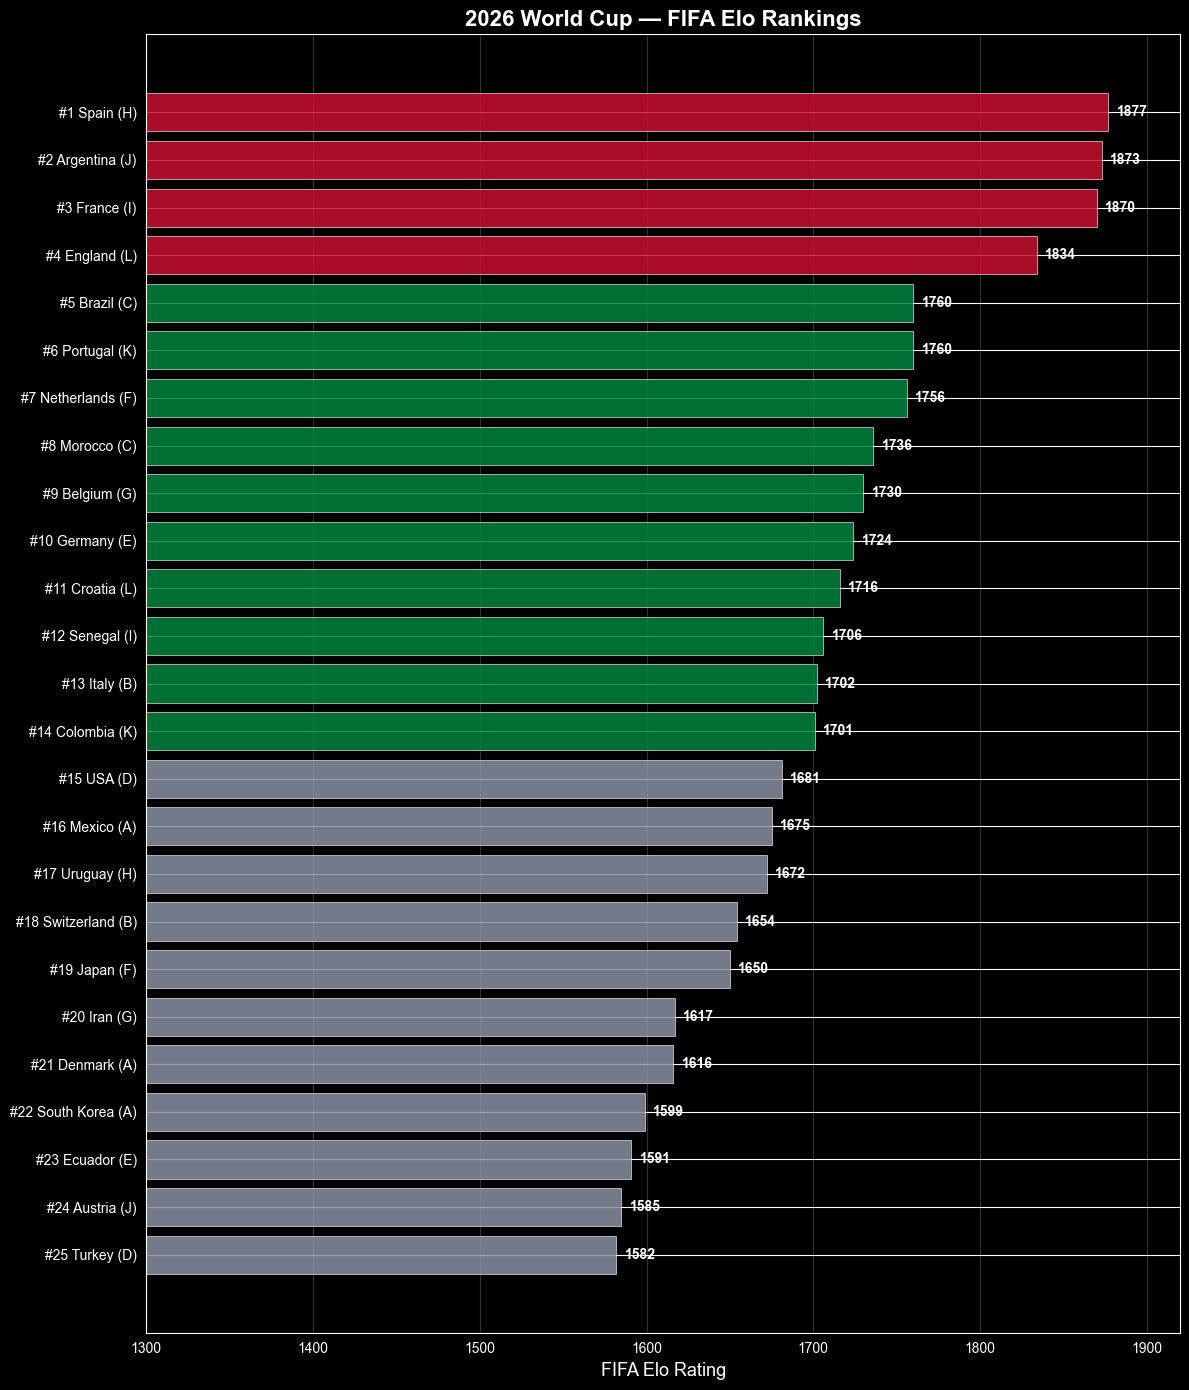

In [7]:
fig, ax = plt.subplots(figsize=(12, 14))

top25 = team_data.head(25)
colors = ['#c8102e' if e >= 1800 else '#00843d' if e >= 1700 else '#8892a4'
          for e in top25['elo']]

bars = ax.barh(range(len(top25)), top25['elo'], color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(top25)))
ax.set_yticklabels([f"#{i+1} {row['team']} ({row['group']})"
                     for i, (_, row) in enumerate(top25.iterrows())])
ax.invert_yaxis()
ax.set_xlabel('FIFA Elo Rating', fontsize=13)
ax.set_title('2026 World Cup — FIFA Elo Rankings', fontsize=16, fontweight='bold')
ax.grid(axis='x', alpha=0.2)
ax.set_xlim(1300, 1920)

for i, (_, row) in enumerate(top25.iterrows()):
    ax.text(row['elo'] + 5, i, f"{int(row['elo'])}",
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/09_elo_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Top 6 Contenders — Champion DNA Radar

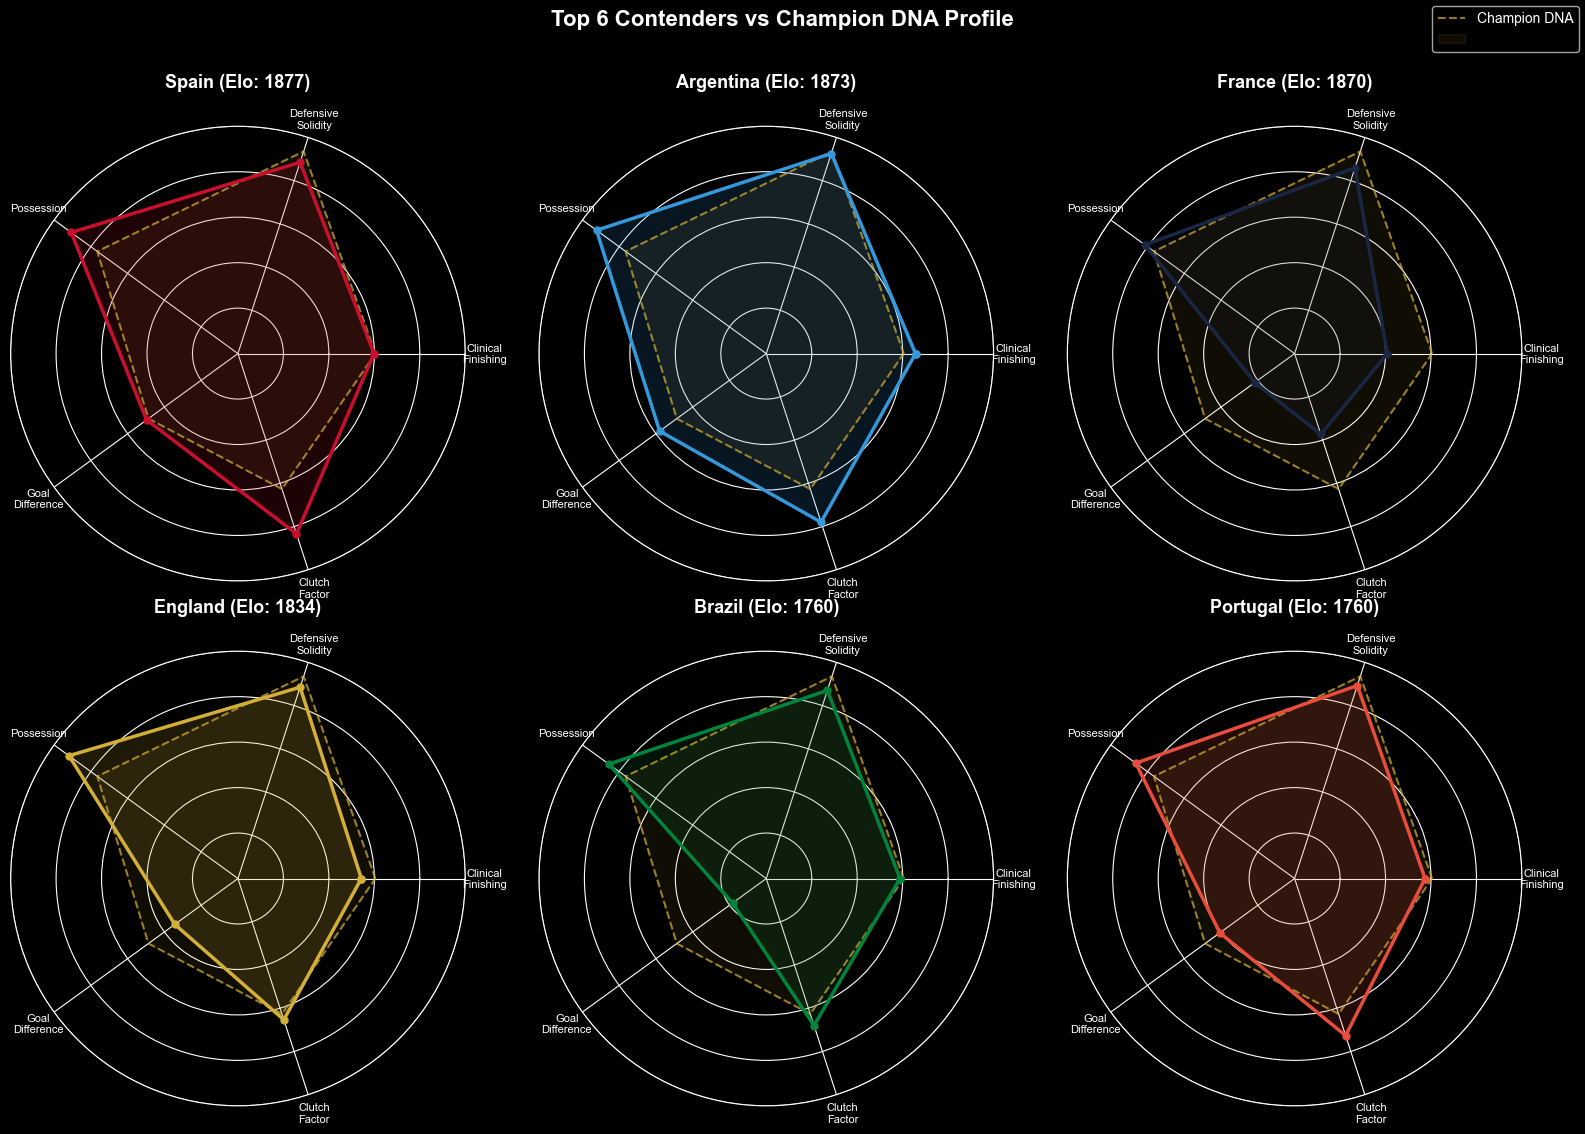

In [8]:
top6 = team_data[team_data['total_matches'] > 0].head(6)

radar_metrics = [
    ('shot_conversion', 'Clinical\nFinishing', 25),
    ('defensive_save_rate', 'Defensive\nSolidity', 100),
    ('possession', 'Possession', 70),
    ('goal_difference', 'Goal\nDifference', 3),
    ('xg_overperformance', 'Clutch\nFactor', 1.5),
]

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

# Champion benchmark line
champ_vals = []
for feat, _, max_val in radar_metrics:
    v = CHAMPION_BENCHMARK[feat] / max_val
    if max_val <= 2:
        v = max(0, min(1, v + 0.5))
    champ_vals.append(max(0, min(1, v)))
champ_vals += champ_vals[:1]

fig, axes = plt.subplots(2, 3, figsize=(16, 11), subplot_kw=dict(polar=True))
axes = axes.flatten()
team_colors = ['#c8102e', '#3498DB', '#1a2744', '#D4AF37', '#00843d', '#E74C3C']

for idx, (_, row) in enumerate(top6.iterrows()):
    ax = axes[idx]
    team_vals = []
    for feat, _, max_val in radar_metrics:
        v = row[feat] / max_val if pd.notna(row[feat]) else 0
        if max_val <= 2:
            v = max(0, min(1, v + 0.5))
        team_vals.append(max(0, min(1, v)))
    team_vals += team_vals[:1]

    ax.plot(angles, champ_vals, '--', color='#D4AF37', linewidth=1.5, alpha=0.7, label='Champion DNA')
    ax.fill(angles, champ_vals, color='#D4AF37', alpha=0.08)
    ax.plot(angles, team_vals, 'o-', color=team_colors[idx], linewidth=2.5, markersize=5)
    ax.fill(angles, team_vals, color=team_colors[idx], alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m[1] for m in radar_metrics], size=8)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.set_title(f"{row['team']} (Elo: {int(row['elo'])})", fontsize=13, fontweight='bold', pad=15)

fig.suptitle('Top 6 Contenders vs Champion DNA Profile', fontsize=16, fontweight='bold', y=1.02)
fig.legend(['Champion DNA', ''], loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/10_champion_dna_radar.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Key Metrics — Top 12 vs Champion Benchmark

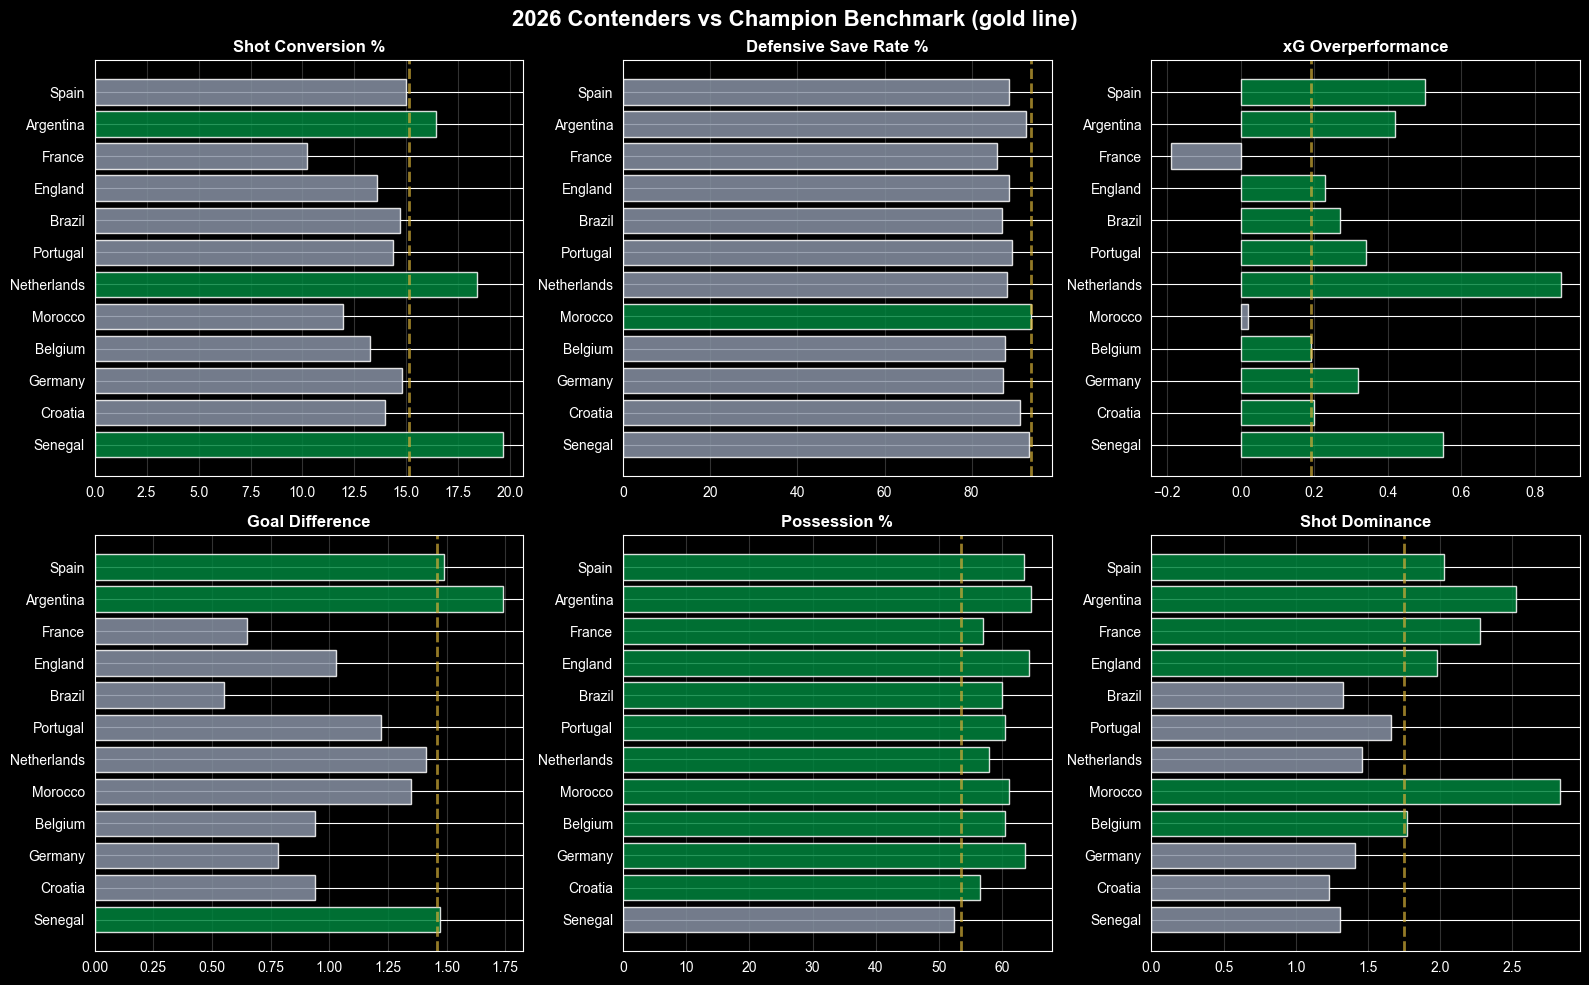

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

compare_features = [
    ('shot_conversion', 'Shot Conversion %'),
    ('defensive_save_rate', 'Defensive Save Rate %'),
    ('xg_overperformance', 'xG Overperformance'),
    ('goal_difference', 'Goal Difference'),
    ('possession', 'Possession %'),
    ('shot_dominance', 'Shot Dominance'),
]

top12 = team_data[team_data['total_matches'] > 0].head(12)

for i, (feat, label) in enumerate(compare_features):
    ax = axes[i]
    teams = top12['team'].tolist()[::-1]
    values = top12[feat].tolist()[::-1]
    benchmark = CHAMPION_BENCHMARK.get(feat, None)

    colors = ['#00843d' if (benchmark and v >= benchmark) else '#8892a4' for v in values]
    ax.barh(teams, values, color=colors, alpha=0.85)

    if benchmark:
        ax.axvline(x=benchmark, color='#D4AF37', linestyle='--', linewidth=2, alpha=0.7)

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.2)

fig.suptitle('2026 Contenders vs Champion Benchmark (gold line)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/11_metrics_vs_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export

Two separate exports:
1. **Elo ratings** → used by match prediction & simulator (notebooks 03–04)
2. **Team profiles** → used by the React dashboard for team pages & comparisons

In [10]:
import json

# Export 1: Elo ratings for prediction pipeline
elo_export = team_data[['team', 'group', 'elo']].copy()
elo_export.to_csv('../data/processed/team_strength_ratings.csv', index=True)

# Export 2: Full team profiles for dashboard (JSON)
dashboard_data = []
for _, row in team_data.iterrows():
    profile = {
        'team': row['team'],
        'group': row['group'],
        'elo': int(row['elo']),
        'profile': {
            'shot_conversion': round(row['shot_conversion'], 2) if pd.notna(row['shot_conversion']) else None,
            'shot_accuracy': round(row['shot_accuracy'], 2) if pd.notna(row['shot_accuracy']) else None,
            'defensive_save_rate': round(row['defensive_save_rate'], 2) if pd.notna(row['defensive_save_rate']) else None,
            'xg_overperformance': round(row['xg_overperformance'], 2) if pd.notna(row['xg_overperformance']) else None,
            'goal_difference': round(row['goal_difference'], 2) if pd.notna(row['goal_difference']) else None,
            'possession': round(row['possession'], 2) if pd.notna(row['possession']) else None,
            'shot_dominance': round(row['shot_dominance'], 2) if pd.notna(row['shot_dominance']) else None,
            'goals_per_match': round(row['goals_pm'], 2) if pd.notna(row['goals_pm']) else None,
            'conceded_per_match': round(row['conceded_pm'], 2) if pd.notna(row['conceded_pm']) else None,
        },
        'matches_analyzed': int(row['total_matches']) if pd.notna(row['total_matches']) else 0,
    }
    dashboard_data.append(profile)

with open('../data/processed/team_profiles.json', 'w') as f:
    json.dump(dashboard_data, f, indent=2)

print(f"Exported {len(team_data)} teams:")
print(f"  → data/processed/team_strength_ratings.csv  (Elo for prediction)")
print(f"  → data/processed/team_profiles.json          (profiles for dashboard)")

Exported 48 teams:
  → data/processed/team_strength_ratings.csv  (Elo for prediction)
  → data/processed/team_profiles.json          (profiles for dashboard)


## 9. Conclusions

### Pipeline Role
This notebook serves as the data bridge between historical analysis (notebook 01) and prediction (notebooks 03–04):
- **Elo ratings** feed directly into the match prediction model — pure Elo, no adjustments, because the FIFA system already accounts for opponent quality, match importance, and recent form
- **Team profiles** feed the dashboard — individual metrics that show *how* each team plays, compared against the World Cup champion benchmark from notebook 01

### Key Insight
The form metrics (shot conversion, defensive save rate, xG overperformance, etc.) are valuable for understanding team identity, but they should **not** be mixed into prediction. Elo already captures form through its update mechanism — blending in raw stats would double-count recent results while re-introducing opposition quality bias.

### Next Steps
- **Notebook 03:** Use Elo ratings in `match_prediction.ipynb` to calculate P(A beats B)
- **Notebook 04:** Use match predictions in `tournament_simulator.ipynb` for Monte Carlo simulation
- **Dashboard:** Display team profiles with radar charts and champion DNA comparisons